### Guildline:  
* What is BLIP?
* Test on CIFAR10


**Note: run on colab**

#### What is BLIP?
BLIP (Bootstrapping Language-Image Pre-training) combining computer vision and natural language processing (NLP) tasks. In this homework, we use BLIP to implement `image-text-matching`.  

Since BLIP can process more than one type of data, BLIP is a `multimodal` model.

#### Test on CIFAR10
1. load the BLIP model
2. download the CIFAR10 dataset
3. randomly choose a image and decide text, then pass to BLIP model to see if they are matched.

[ref](https://www.kaggle.com/code/youssef19/image-to-text-matching-system)

In [66]:
!pip install transformers
!pip install termcolor

In [50]:
from transformers import AutoProcessor, BlipForImageTextRetrieval

# Load the processor and model
processor = AutoProcessor.from_pretrained("Salesforce/blip-itm-base-coco")
model = BlipForImageTextRetrieval.from_pretrained("Salesforce/blip-itm-base-coco")

download dataset

In [53]:
# Take CIFAR dataset to test
import torch
from torchvision.datasets import CIFAR10
from torchvision import transforms

batch_size = 4
transform = transforms.Compose(
    [
      transforms.ToTensor(),
      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
     ])


dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                      shuffle=True, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

represent data in graph

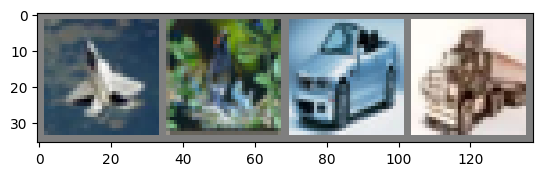

plane bird  car   truck


In [54]:
import matplotlib.pyplot as plt
import torchvision
import numpy as np


# functions to show an image

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images (pad together)
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

get image input

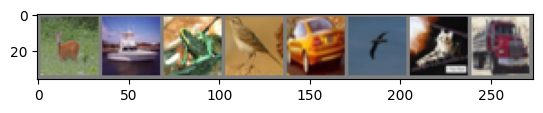

deer ship frog bird car bird cat truck


In [92]:
from PIL import Image
# get some random training images
# dataiter = iter(trainloader)
# images, labels = next(dataiter)

# print(images.shape) # [batch_size, channel, height, width] = [4, 3, 32, 32]

# take 2 batch to test
image_tensor = []
image_label = []
for i, (images, labels) in enumerate(trainloader):
  if i == 2:
    break

  for idx in range(len(images)):
    image_tensor.append(images[idx])
    image_label.append(labels[idx])


# Now, we have choosed 8 image
# print what we have choosed
imshow(torchvision.utils.make_grid(image_tensor))
# print corresponding class names
print(' '.join(f'{classes[label]}' for label in image_label))

# prepross for BILP input

# 定義轉換器
to_pil = transforms.ToPILImage()

# 存儲轉換後的結果
resized_pil_images = []

for img_tensor in image_tensor:
    # unnormalize: from [-1, 1] to [0, 1]
    img_tensor = img_tensor / 2 + 0.5

    # tensor → PIL
    img_pil = to_pil(img_tensor)

    # resize 成 224x224 給 BLIP
    img_resized = img_pil.resize((224, 224))

    # 加進 list 裡
    resized_pil_images.append(img_resized)

generate text input based on image

In [93]:
# image have been processed, then define text input
text_list = [
    "There is a deer.",
    "What a nice scenery!",
    "Look! There is a frog.",
    "The bird is standing on the table.",

    "There is a yellow car.",
    "The bird is flying in the sky.",
    "I love cat.",
    "Truck is so big.",
]

wrap as function to do the inference

Here we define the `Matching Score` threshold = 0.5.  
If the number exceeds this value, we may consider that Image and Text are Matching!

In [ ]:
from termcolor import colored # I want to modify the color, but it seems to not working.

# 顯示匹配結果與分數
def show_match_result(itm_score):
    print("="*40)
    match_score = itm_score[0][1]
    print("🔍 相似度分數 (Matching Score):", f"{match_score:.4f}")

    if match_score >= 0.5:
        print(colored("✅ 判斷結果：Image and Text are Match!", "green"))
    else:
        print(colored("❌ 判斷結果：Image and Text are NOT Match!", "red"))

    print("="*40)


def image_text_matching(processor, model, img, text):
  """
    processor: encode the image and text
    model: for image-text-matching task models like CLIP or BLIP
    img: a PIL image (dtype: np.array)
    text: a string that describe the image (dtype: string)
  """

  # 處理輸入
  inputs = processor(images=img, text=text, return_tensors="pt")

  # 模型預測
  with torch.no_grad():
    outputs = model(**inputs)[0]

  itm_score = torch.nn.functional.softmax(outputs, dim=1) # [not_match_probability, match_probability]

  # print result
  show_match_result(itm_score)

Because CIFAR10 are default 32x32, and we resize to 224x224, so it will have lower resolution which cause BLIP to think about that they text and image are different.  

因為原本的圖片很小，經過放大之後導致圖片變模糊，以致於不太能夠辨識出圖片裡面的東西，所以就算 label 有在文字敘述內出現，卻還是有可能被認為不相似。

In [94]:
for i, (img, label, text) in enumerate(zip(resized_pil_images, image_label, text_list)):
  print(f"Case {i+1}:")
  print(f"The given label is \"{classes[label]}\" and given text is \"{text}\"")
  image_text_matching(processor, model, img, text)

Case 1:
The given label is "deer" and given text is "There is a deer."
🔍 相似度分數 (Matching Score): 0.8507
✅ 判斷結果：Image and Text are Match!
Case 2:
The given label is "ship" and given text is "What a nice scenery!"
🔍 相似度分數 (Matching Score): 0.1861
❌ 判斷結果：Image and Text are NOT Match!
Case 3:
The given label is "frog" and given text is "Look! There is a frog."
🔍 相似度分數 (Matching Score): 0.5638
✅ 判斷結果：Image and Text are Match!
Case 4:
The given label is "bird" and given text is "The bird is standing on the table."
🔍 相似度分數 (Matching Score): 0.8978
✅ 判斷結果：Image and Text are Match!
Case 5:
The given label is "car" and given text is "There is a yellow car."
🔍 相似度分數 (Matching Score): 0.9500
✅ 判斷結果：Image and Text are Match!
Case 6:
The given label is "bird" and given text is "The bird is flying in the sky."
🔍 相似度分數 (Matching Score): 0.8664
✅ 判斷結果：Image and Text are Match!
Case 7:
The given label is "cat" and given text is "I love cat."
🔍 相似度分數 (Matching Score): 0.1262
❌ 判斷結果：Image and Text are NOT